# Social Capital & Community Data

## Importing Libraries & Dataset

In [25]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# social capital economic mobility dataset
df_scem = pd.read_csv("social_capital_county_economic_mobility.csv")
df_scem = df_scem[['ec_county', 'child_ec_county', 'support_ratio_county', 'volunteering_rate_county', 'civic_organizations_county', 'clustering_county']]
print(df_scem.shape)
df_scem.head()

(3089, 6)


,ec_county,child_ec_county,support_ratio_county,volunteering_rate_county,civic_organizations_county,clustering_county
0,0.72077,1.11754,0.98275,0.04355,0.01518,0.10347
1,0.74313,0.83064,0.98684,0.06117,0.01526,0.09624
2,0.41366,0.58541,0.99911,0.02093,0.01474,0.14911
3,0.63152,0.72265,0.99716,0.05294,0.01439,0.14252
4,0.72562,0.76096,0.99069,0.05704,0.01724,0.11243


3089 rows & 6 columns in dataset

### Columns:

**Economic Connectedness:** How connected lower-income people are to higher-income people socially. Higher values usually mean more cross-class friendships/connections

**Childhood Economic Conectedness:** Economic connectedness measured for children or based on childhood social environments

**Social Support Ratio:** A measure of how much social support exists in that community, maybe based on friendship/support networks

**Volunteering Rate:** The percentage/rate of people who volunteer

**Civic Organizatons Rate:** How common participation in civic/community organizations is

**Social Network Clustering:** How tightly people’s friend groups are connected. High clustering means “my friends are also friends with each other.”

In [20]:
df_scem.info()
df_scem.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3089 entries, 0 to 3088
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ec_county                   3018 non-null   float64
 1   child_ec_county             2729 non-null   float64
 2   support_ratio_county        3089 non-null   float64
 3   volunteering_rate_county    3089 non-null   float64
 4   civic_organizations_county  3089 non-null   float64
 5   clustering_county           3089 non-null   float64
dtypes: float64(6)
memory usage: 144.9 KB


,ec_county,child_ec_county,support_ratio_county,volunteering_rate_county,civic_organizations_county,clustering_county
count,3018.000000,2729.000000,3089.000000,3089.000000,3089.000000,3089.000000
mean,0.814464,0.825335,0.988901,0.078068,0.019762,0.116456
std,0.177126,0.221210,0.015467,0.034841,0.009850,0.020364
min,0.294690,0.221880,0.696760,0.009650,0.003490,0.071620
25%,0.695607,0.678750,0.986830,0.055280,0.014020,0.102690
50%,0.806830,0.815510,0.993740,0.073280,0.017780,0.114570
75%,0.936783,0.962130,0.996720,0.093960,0.023060,0.127240
max,1.359700,1.611360,1.000000,0.308736,0.195429,0.260970


- All variables are numeric

- Some missing data -- 71 in economic connectedness, 360 in childhood economic connectedness

- Possible right-skew/high outliers in:
    1. volunteering rate (mean 0.078, med 0.073, max 0.309): max is much higher than where most counties fall
    1. civic organization rate (mean 0.020, med 0.018, max 0.195): max is way above 75% percentile
    1. social support ratio (mean 0.989, med 0.994, min 0.697, max 1.000): most numbers seem to be around 1, but the minimum is much lower

## Visualizations

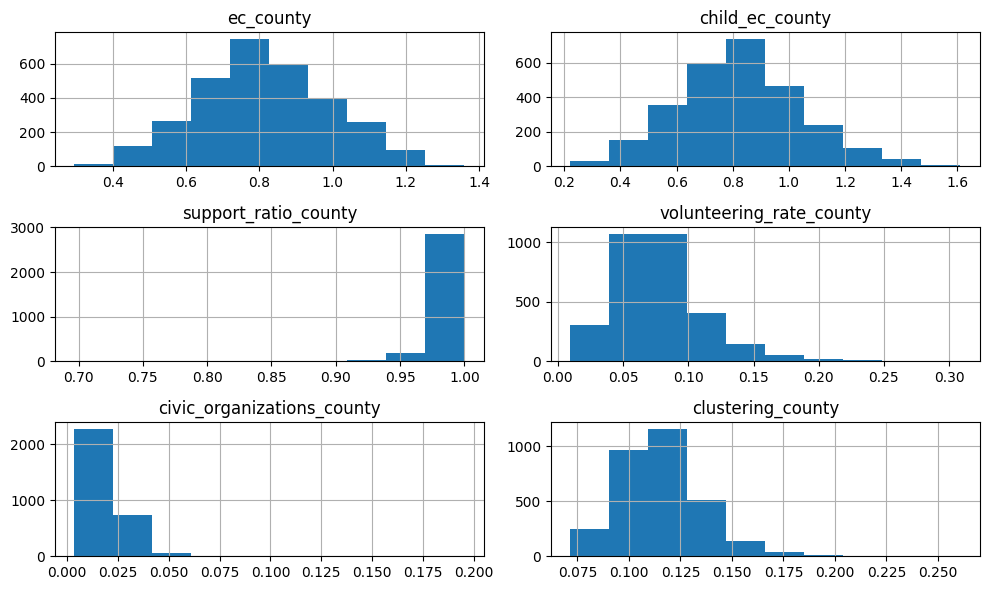

In [ ]:
# histograms
df_scem.hist(figsize=(10,6))
plt.tight_layout()
plt.show()

- Economic connectedness and childhood economic connectedness seem to be fairly normally distributed
- Social support ratio has an extreme left-skew, which was mentioned briefly earlier
- Volunteering rate, civic organization rate, and social network clustering have strong right-skews, especially civic organization rate with majority of its values between 0 and 0.025.

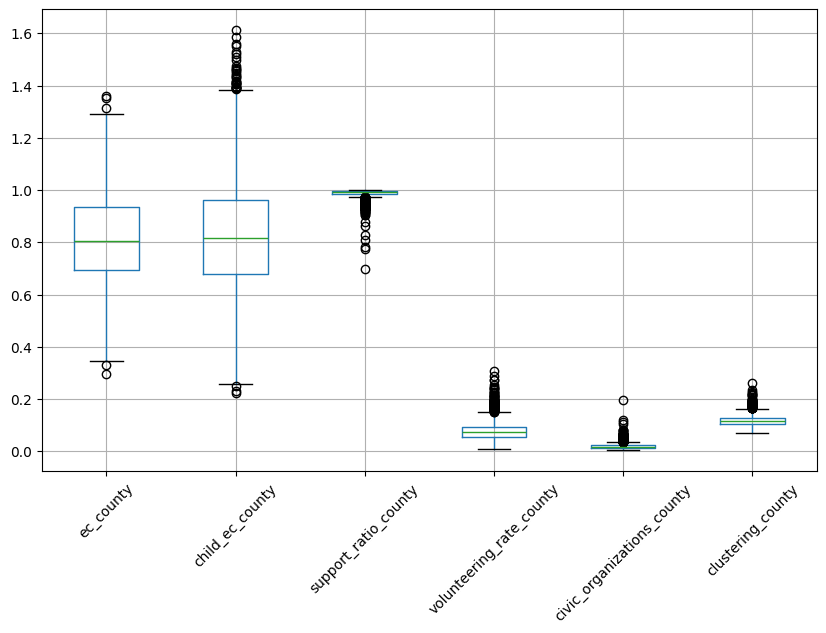

In [ ]:
# boxplots
df_scem.boxplot(figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

Same observations as above with the histograms. Outliers seem to be extremely common in this dataset.

In [ ]:
# checking correlation between variables
df_scem.corr()

,ec_county,child_ec_county,support_ratio_county,volunteering_rate_county,civic_organizations_county,clustering_county
ec_county,1.000000,0.615241,-0.268590,0.390049,0.370408,-0.270103
child_ec_county,0.615241,1.000000,-0.465381,0.132104,0.085321,-0.482048
support_ratio_county,-0.268590,-0.465381,1.000000,0.024665,-0.009087,0.524740
volunteering_rate_county,0.390049,0.132104,0.024665,1.000000,0.282239,-0.037363
civic_organizations_county,0.370408,0.085321,-0.009087,0.282239,1.000000,0.039453
clustering_county,-0.270103,-0.482048,0.524740,-0.037363,0.039453,1.000000


There does not seem to be an issue with multicollinearity in this dataset. The highest correlations between predictors (if economic connectedness is outcome) are between clustering rate and social support rate, which makes sense since a tighter-knit community would likely exhibit more social support.

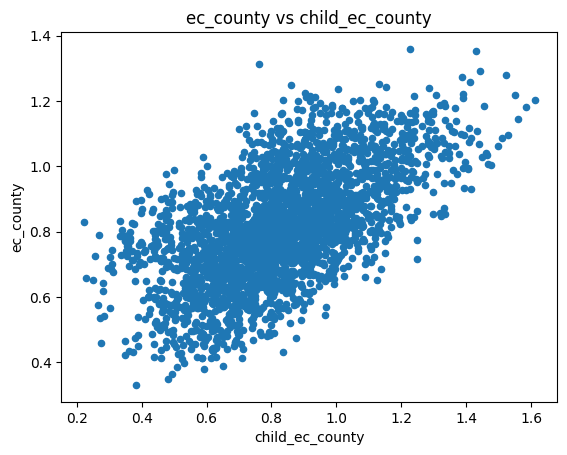

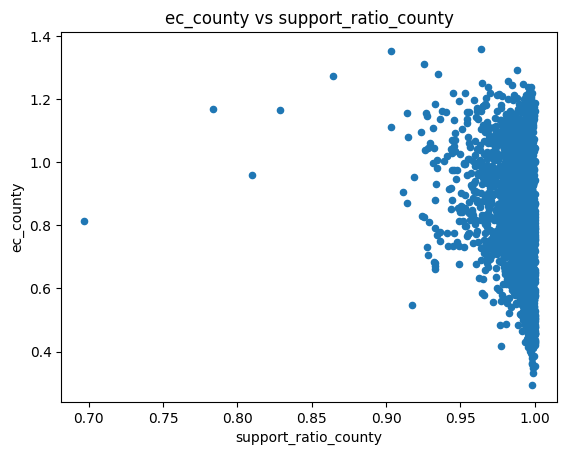

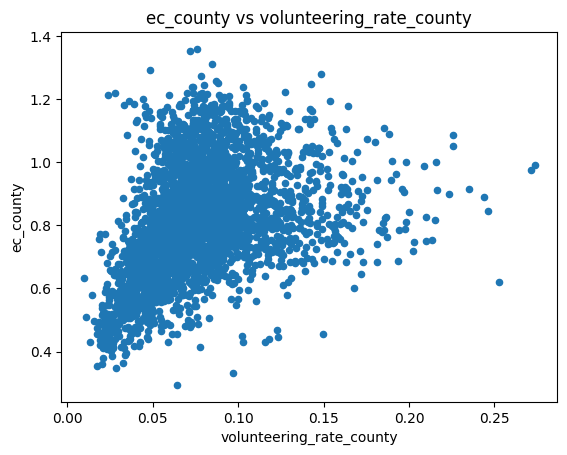

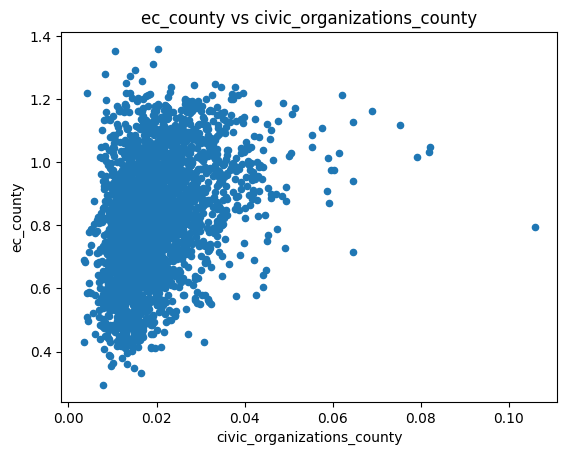

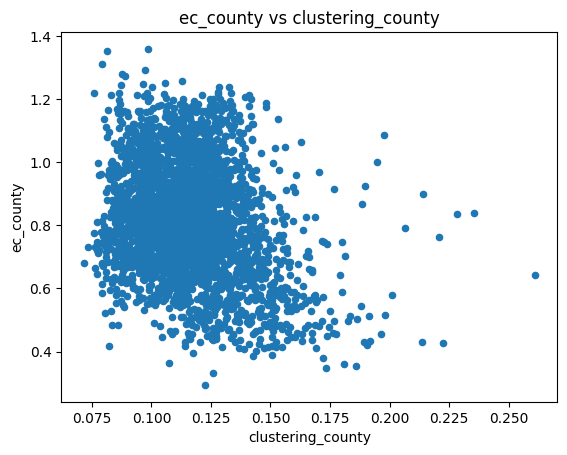

In [ ]:
# scatterplots with economic connectedness as outcome variable
predictors = [
    "child_ec_county",
    "support_ratio_county",
    "volunteering_rate_county",
    "civic_organizations_county",
    "clustering_county"
]

for col in predictors:
    df_scem.plot.scatter(x=col, y="ec_county")
    plt.title(f"ec_county vs {col}")
    plt.show()

- Moderate positive relationship between childhood ec and general ec
- No observed relationship between ec and social support ratio
- Weak positive relationship between volunteering rate and ec
- Weak positive relationship between ec and civic organization rate
- No observed relationship between ec and social network clustering

Overall, the county-level social capital measures that seem to be most strongly related to economic connectedness are childhood economic connectedness (trivial), volunteering rate, and civic organization rate (in that order).